# 과제 - 신경망을 이용한 손글씨 숫자 인식



## 1. 환경설정



In [5]:
# Colab: 이 셀을 가장 먼저 실행하세요 (저장소 클론 후 경로·모듈 로드)
# 주의: Colab에서는 GitHub 저장소 URL과 Personal Access Token을 반드시 입력해야 합니다.
import os
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    from getpass import getpass

    git_url = input("GitHub 저장소 URL (예: github.com/USERNAME/mnist-lab.git): ").strip()
    token = getpass("GitHub Personal Access Token (private 저장소인 경우): ")

    # URL 마지막 경로를 저장소 폴더명으로 사용합니다. (예: .../mnist-lab.git -> mnist-lab)
    repo_name = Path(git_url.rstrip("/")).name
    if repo_name.endswith(".git"):
        repo_name = repo_name[:-4]

    !git clone https://{token}@{git_url}
    os.chdir(repo_name)
    sys.path.insert(0, str(Path.cwd() / "src"))
else:
    sys.path.insert(0, "src")


## 2. 데이터 로드

In [36]:
import sys
from pathlib import Path

repo_root = Path(r"C:\Dev\Crafton-Jungle\04.AI\wk13_6_mnist")
src_path = str(repo_root / "src")

if src_path in sys.path:
    sys.path.remove(src_path)
sys.path.insert(0, src_path)

for name in ["network", "optimizers", "training", "layers", "activations", "losses"]:
    if name in sys.modules:
        del sys.modules[name]

## 3. 구현 및 테스트 통과 확인

`src/` 아래 역할별 파일의 **TODO**를 순서대로 구현한 뒤 아래 셀을 실행하세요.
- 주요 구현 파일: `activations.py`, `layers.py`, `losses.py`, `optimizers.py`, `network.py`, `training.py`
- 구현 파일은 역할별 모듈을 직접 import합니다. 예: `from network import NeuralNetwork`
- 개발 순서: 과제 안내문 참조
- 테스트: `tests/` 아래의 단계별 단위 테스트를 필요한 파일부터 실행합니다. 처음에는 전체 테스트보다 맡은 부분의 테스트 파일을 먼저 실행하세요.
    - ReLU만 확인: `TEST_TARGET = "tests/test_relu.py"`
    - 파일 안의 일부 테스트만 확인: `PYTEST_KEYWORD = "backward"`
    - 전체 테스트 확인: `TEST_TARGET = "tests/"`

In [37]:
import subprocess
import sys
from pathlib import Path

# Colab/로컬 모두 현재 노트북 실행 위치를 저장소 루트로 사용합니다.
repo_dir = Path.cwd()

# 처음에는 자신이 구현 중인 부분의 테스트 파일만 실행하세요.
# 예: tests/test_relu.py, tests/test_affine.py, tests/test_training.py
TEST_TARGET = "tests/"

# 특정 이름이 들어간 테스트만 실행하고 싶을 때 사용합니다.
# 예: "backward". 전체 파일을 실행하려면 빈 문자열로 둡니다.
PYTEST_KEYWORD = ""

cmd = [sys.executable, "-m", "pytest", TEST_TARGET, "-v"]
if PYTEST_KEYWORD:
    cmd.extend(["-k", PYTEST_KEYWORD])

print("실행 경로:", repo_dir)
print("실행 명령:", " ".join(cmd))
result = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
    cwd=str(repo_dir)
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
if result.returncode == 0:
    print("\n선택한 테스트를 통과했습니다.")
else:
    print("\n선택한 테스트 중 실패가 있습니다.")


실행 경로: c:\Dev\Crafton-Jungle\04.AI\wk13_6_mnist
실행 명령: c:\Users\이혜연\.conda\envs\mnist-nn\python.exe -m pytest tests/ -v
============================= test session starts =============================
platform win32 -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- c:\Users\이혜연\.conda\envs\mnist-nn\python.exe
cachedir: .pytest_cache
rootdir: c:\Dev\Crafton-Jungle\04.AI\wk13_6_mnist
collecting ... collected 21 items

tests/test_adam.py::TestAdam::test_adam_update_changes_params PASSED     [  4%]
tests/test_affine.py::TestAffine::test_affine_forward_shape PASSED       [  9%]
tests/test_affine.py::TestAffine::test_affine_backward_grad_shape PASSED [ 14%]
tests/test_batchnorm.py::TestBatchNorm::test_batchnorm_forward_shape PASSED [ 19%]
tests/test_batchnorm.py::TestBatchNorm::test_batchnorm_backward_shape PASSED [ 23%]
tests/test_cross_entropy_loss.py::TestCrossEntropyLoss::test_cross_entropy_loss_scalar PASSED [ 28%]
tests/test_cross_entropy_loss.py::TestCrossEntropyLoss::test_cross_entropy

## 4. 모델·옵티마이저 생성 및 학습

In [ ]:
from network import NeuralNetwork
from optimizers import Adam
from training import train

model = NeuralNetwork(use_batchnorm=True, use_dropout=True)  # BatchNorm, Dropout 필수
optimizer = Adam(lr=0.001)

loss_history = train(model, optimizer, x_train, y_train, epochs=50, batch_size=128)

## 5. 평가 및 손실 커브

Test Accuracy: 98.56%
Total Params: 537,354


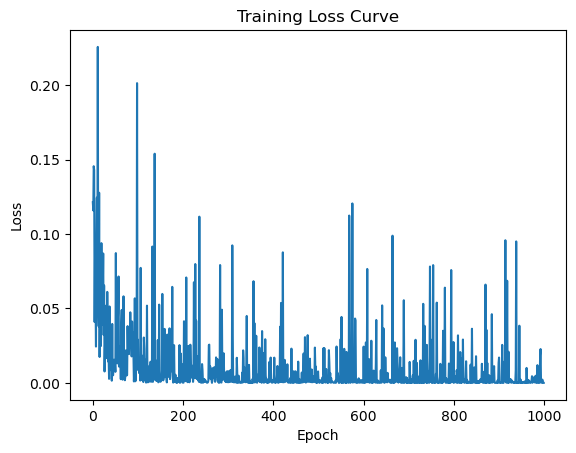

In [48]:
from training import evaluate, plot_loss_history

acc, n_params = evaluate(model, x_test, y_test)
print(f'Test Accuracy: {acc:.2f}%')
print(f'Total Params: {n_params:,}')

plot_loss_history(loss_history)